<a href="https://colab.research.google.com/github/Ireneunav/TFM_MCD25/blob/main/Modelo_prediccion_madrid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelos de predicción

Las tablas que se han creado en el script 'Funcion_gradillas_estaciones.ipynb' estan guardadas por separado en Drive, por lo que las vamos a juntar y vamos a lanzar un modelo multilayer perceptron.

## Cargamos los datos

In [ ]:
import numpy as np
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

ee_data = pd.read_csv('/content/drive/MyDrive/Máster/TFM/Resultados/tabla_madrid_mensual_16-20_estICA.csv', decimal=',')
sociodem_data = pd.read_csv('/content/drive/MyDrive/Máster/TFM/Resultados/sociodem_madrid.csv', decimal='.')
crec_pob_nav16 = pd.read_csv('/content/drive/MyDrive/Máster/TFM/crecimiento_pob_madrid_2016.csv', decimal='.', sep=';')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
sociodem_data = sociodem_data.rename(columns={"cod_local":"id"}) #para poder unir las columnas tenemos que cambiarle el nombre a alguna

In [ ]:
# rellenar sociodem (tasa de crecimiento de 2016)
# Los datos de crecimiento de población de 2016 no fueron descargados y los rellenamos con una tabla obtenida por separado

cambiar = sociodem_data[sociodem_data['periodo']==2016][['tasa_crecimiento_pct', 'codigo_ine']]
cambiado = pd.merge(cambiar, crec_pob_nav16, on='codigo_ine', how='left', suffixes=("", "_new"))
for n in range(cambiar.shape[0]):
  sociodem_data.loc[cambiar.index[n], 'tasa_crecimiento_pct'] = cambiado['tasa_crecimiento_pct_new'].iloc[n]
sociodem_data

,id,periodo,codigo_ine,pct_area_viaria,pnc_jubilacion_per_1000,pnc_invalidez_per_1000,pnc_total_per_1000,densidad_poblacion_hab_km2,tasa_crecimiento_pct,clasificacion,...,pct_forestal_osm,pct_parque,area_parque_m2_per_hab,area_verde_m2_per_hab,area_forestal_m2_per_hab,parques_per_1000hab,area_parque_m2_per_1000hab,pct_agua,pct_humedal,pct_ribera
0,28005002,2016,28005,NaN,3.672339,2.385497,6.057836,2222.98,-1.4304,Urbano,...,NaN,NaN,9.063484,10.913852,101.398112,0.653371,9063.484204,NaN,NaN,NaN
1,28005002,2017,28005,NaN,0.381886,2.422553,6.241563,2204.86,-0.8152,Urbano,...,NaN,NaN,9.137975,11.003551,102.231486,0.658741,9137.975400,NaN,NaN,NaN
2,28005002,2018,28005,NaN,3.929415,2.413167,6.342581,2198.52,-0.2877,Urbano,...,NaN,NaN,9.164340,11.035298,102.526439,0.660642,9164.339797,NaN,NaN,NaN
3,28005002,2019,28005,NaN,4.057692,2.344451,6.402143,2220.05,0.9796,Urbano,...,NaN,NaN,9.075436,10.928244,101.531825,0.654233,9075.436113,NaN,NaN,NaN
4,28005002,2020,28005,NaN,3.989446,2.239565,6.229011,2241.76,0.9778,Urbano,...,NaN,NaN,8.987558,10.822425,100.548689,0.647898,8987.558336,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403,28180001,2019,28180,NaN,4.057692,2.344451,6.402143,61.64,0.6035,Rural,...,NaN,NaN,1.322427,1.322427,6.571234,1.226994,1322.426721,NaN,NaN,NaN
404,28180001,2020,28180,NaN,3.989446,2.239565,6.229011,62.47,1.3361,Rural,...,NaN,NaN,1.304991,1.304991,6.484596,1.210817,1304.991255,NaN,NaN,NaN
405,28180001,2021,28180,NaN,0.409406,2.170857,6.265061,63.47,1.6010,Rural,...,NaN,NaN,1.284428,1.284428,6.382415,1.191737,1284.427966,NaN,NaN,NaN
406,28180001,2022,28180,NaN,3.983802,2.028788,6.012590,64.11,1.0196,Rural,...,NaN,NaN,1.271464,1.271464,6.317997,1.179709,1271.464150,NaN,NaN,NaN


In [ ]:
sociodem_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 408 entries, 0 to 407
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id                             408 non-null    int64  
 1   periodo                        408 non-null    int64  
 2   codigo_ine                     408 non-null    int64  
 3   pct_area_viaria                51 non-null     float64
 4   pnc_jubilacion_per_1000        408 non-null    float64
 5   pnc_invalidez_per_1000         408 non-null    float64
 6   pnc_total_per_1000             408 non-null    float64
 7   densidad_poblacion_hab_km2     408 non-null    float64
 8   tasa_crecimiento_pct           408 non-null    float64
 9   clasificacion                  408 non-null    object 
 10  ratio_poblacion_area           408 non-null    float64
 11  autonomia_financiera_pct       390 non-null    float64
 12  residuos_kg_habitante          408 non-null    flo

In [ ]:
# rellenar las columnas vacias de sociodem_data con los mismos datos
vacias = sociodem_data.columns[sociodem_data.notna().sum()< (sociodem_data.shape[0])].tolist()
columnas_vacias = vacias + ['codigo_ine'] #seleccionamos las columnas con registros vacíos + la columna por la que agruparemos para rellenar los datos
sociodem_data[columnas_vacias] = sociodem_data[columnas_vacias].fillna(sociodem_data.groupby('codigo_ine')[columnas_vacias].transform("mean"))
sociodem_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 408 entries, 0 to 407
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id                             408 non-null    int64  
 1   periodo                        408 non-null    int64  
 2   codigo_ine                     408 non-null    int64  
 3   pct_area_viaria                408 non-null    float64
 4   pnc_jubilacion_per_1000        408 non-null    float64
 5   pnc_invalidez_per_1000         408 non-null    float64
 6   pnc_total_per_1000             408 non-null    float64
 7   densidad_poblacion_hab_km2     408 non-null    float64
 8   tasa_crecimiento_pct           408 non-null    float64
 9   clasificacion                  408 non-null    object 
 10  ratio_poblacion_area           408 non-null    float64
 11  autonomia_financiera_pct       400 non-null    float64
 12  residuos_kg_habitante          408 non-null    flo

In [ ]:
# los valores vacios de autonomia financiera pertenecen al mismo municipio, y si agrupamos para rellenar por municipio, no encuentra nada con que rellenar
vacias2 = sociodem_data.columns[sociodem_data.notna().sum()< (sociodem_data.shape[0])].tolist()
columnas_vacias = vacias2 + ['periodo']
sociodem_data[columnas_vacias] = sociodem_data[columnas_vacias].fillna(sociodem_data.groupby('periodo')[columnas_vacias].transform("mean"))
sociodem_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 408 entries, 0 to 407
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id                             408 non-null    int64  
 1   periodo                        408 non-null    int64  
 2   codigo_ine                     408 non-null    int64  
 3   pct_area_viaria                408 non-null    float64
 4   pnc_jubilacion_per_1000        408 non-null    float64
 5   pnc_invalidez_per_1000         408 non-null    float64
 6   pnc_total_per_1000             408 non-null    float64
 7   densidad_poblacion_hab_km2     408 non-null    float64
 8   tasa_crecimiento_pct           408 non-null    float64
 9   clasificacion                  408 non-null    object 
 10  ratio_poblacion_area           408 non-null    float64
 11  autonomia_financiera_pct       408 non-null    float64
 12  residuos_kg_habitante          408 non-null    flo

In [ ]:
# Rellenamos los registros vacíos de la tabla de datos obtenidos desde Google Earth Engine
vacias_ee = ee_data.columns[ee_data.notna().sum() < ee_data.shape[0]].tolist()
columnas_vaciasee = vacias_ee + ['id']
ee_data[columnas_vaciasee] = ee_data[columnas_vaciasee].fillna(ee_data.groupby('id')[columnas_vaciasee].transform("mean"))

In [ ]:
# Convertimos las columnas de fechas a formato 'datetime'
ee_data['periodo'] = pd.to_datetime(ee_data['fecha']).dt.year
ee_data['fecha'] = pd.to_datetime(ee_data['fecha'])
# ee_data['periodo'].dtype
ee_data

,fecha,id,lat,lon,dewpoint_2m_temperature,maximum_2m_air_temperature,mean_2m_air_temperature,mean_sea_level_pressure,minimum_2m_air_temperature,surface_pressure,...,LC_Prop2,LC_Prop2_Assessment,LC_Prop3,LC_Prop3_Assessment,LC_Type1,LC_Type2,LC_Type3,LC_Type4,LC_Type5,periodo
0,2016-01-01,28005002,40.47933,-3.37795,278.095673,290.816589,280.818268,102239.593750,270.538330,94012.968750,...,9,96,30,94,13,13,10,8,9,2016
1,2016-02-01,28005002,40.47933,-3.37795,275.495636,290.284027,280.662384,101973.390625,269.476166,93758.085938,...,9,96,30,94,13,13,10,8,9,2016
2,2016-03-01,28005002,40.47933,-3.37795,274.359802,294.663086,281.666748,101635.398438,271.477417,93470.859375,...,9,96,30,94,13,13,10,8,9,2016
3,2016-04-01,28005002,40.47933,-3.37795,278.193665,295.048767,284.666290,101373.023438,273.070526,93288.492188,...,9,96,30,94,13,13,10,8,9,2016
4,2016-05-01,28005002,40.47933,-3.37795,279.853851,300.933716,288.636627,101435.750000,275.334076,93422.992188,...,9,96,30,94,13,13,10,8,9,2016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3055,2020-08-01,28180001,40.16720,-3.27660,278.705458,300.552000,288.601663,101779.906840,277.341778,94237.040389,...,30,93,30,93,10,10,1,6,6,2020
3056,2020-09-01,28180001,40.16720,-3.27660,278.705458,300.552000,288.601663,101779.906840,277.341778,94237.040389,...,30,93,30,93,10,10,1,6,6,2020
3057,2020-10-01,28180001,40.16720,-3.27660,278.705458,300.552000,288.601663,101779.906840,277.341778,94237.040389,...,30,93,30,93,10,10,1,6,6,2020
3058,2020-11-01,28180001,40.16720,-3.27660,278.705458,300.552000,288.601663,101779.906840,277.341778,94237.040389,...,30,93,30,93,10,10,1,6,6,2020


In [ ]:
# Seleccionamos la última fecha de los datos de fracción de cobertura y tipo de bosque porque está vacía debido a la forma de guardar los datos de Google Earth Engine
col_cop = ee_data.filter(like='coverfraction', axis='columns').columns.tolist() + ['forest_type']
columnas_copernicus = col_cop + ['periodo', 'id']
cambiar = ee_data[columnas_copernicus]
cambiar = cambiar[cambiar['periodo']==2019]
# cambiar
idx = np.where(cambiar.iloc[:,0].isna())[0]
idx

array([], dtype=int64)

In [ ]:
# Rellenamos estos datos de fracción de cobertura y tipo de bosque
cambiado2 = cambiar.copy()
cambiado2[col_cop] = cambiar[col_cop].fillna(cambiar.groupby(['id', 'periodo'])[col_cop].transform("mean"))
idx2 = cambiado2.iloc[idx, :].index
ee_data.loc[idx2, col_cop] = cambiado2.iloc[idx, :]
# ee_data.loc[idx2, col_cop]

In [ ]:
ee_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3060 entries, 0 to 3059
Data columns (total 78 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   fecha                                            3060 non-null   datetime64[ns]
 1   id                                               3060 non-null   int64         
 2   lat                                              3060 non-null   float64       
 3   lon                                              3060 non-null   float64       
 4   dewpoint_2m_temperature                          3060 non-null   float64       
 5   maximum_2m_air_temperature                       3060 non-null   float64       
 6   mean_2m_air_temperature                          3060 non-null   float64       
 7   mean_sea_level_pressure                          3060 non-null   float64       
 8   minimum_2m_air_temperature            

In [ ]:
# Rellenar las columnas vacias restantes en ee_data
columnas_vacias = ee_data.columns[ee_data.notna().sum() < (ee_data.shape[0])].tolist()
columnas_vacias = columnas_vacias + ['fecha']
ee_data[columnas_vacias] = ee_data[columnas_vacias].fillna(ee_data.groupby(['fecha'])[columnas_vacias].transform("mean"))
ee_data.info(show_counts=True, verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3060 entries, 0 to 3059
Data columns (total 103 columns):
 #    Column                                           Non-Null Count  Dtype         
---   ------                                           --------------  -----         
 0    fecha                                            3060 non-null   datetime64[ns]
 1    id                                               3060 non-null   int64         
 2    lat                                              3060 non-null   float64       
 3    lon                                              3060 non-null   float64       
 4    dewpoint_2m_temperature                          3060 non-null   float64       
 5    maximum_2m_air_temperature                       3060 non-null   float64       
 6    mean_2m_air_temperature                          3060 non-null   float64       
 7    mean_sea_level_pressure                          3060 non-null   float64       
 8    minimum_2m_air_temperature

In [ ]:
tabla_unida = pd.merge(ee_data, sociodem_data, on=['id', 'periodo'], how='left')
data = tabla_unida.drop_duplicates()

# data = tabla_unida[~(tabla_unida['periodo'] == np.array(2020,dtype=np.int32))]
# data

## Modelo multi-layer perceptron (MLP) por fechas

Los datos train, val y test de este modelo están separados por año de manera que entrenamos en los primeros 3 años, validamos con el siguiente y testeamos con el último.

In [ ]:
import torch
import torch.optim as optim
import torch.nn as nn

from sklearn.preprocessing import StandardScaler

In [ ]:
data.info(show_counts=True, verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3060 entries, 0 to 3059
Data columns (total 103 columns):
 #    Column                                           Non-Null Count  Dtype         
---   ------                                           --------------  -----         
 0    fecha                                            3060 non-null   datetime64[ns]
 1    id                                               3060 non-null   int64         
 2    lat                                              3060 non-null   float64       
 3    lon                                              3060 non-null   float64       
 4    dewpoint_2m_temperature                          3060 non-null   float64       
 5    maximum_2m_air_temperature                       3060 non-null   float64       
 6    mean_2m_air_temperature                          3060 non-null   float64       
 7    mean_sea_level_pressure                          3060 non-null   float64       
 8    minimum_2m_air_temperature

In [ ]:
data.loc[:, "anno"] = data["fecha"].dt.year
data.loc[:, "mes"] = data["fecha"].dt.month
# data.loc[:, "dia"] = data["fecha"].dt.day

data.drop(columns=["fecha", "periodo"], inplace=True)

In [ ]:
identificadores = data[['id', 'mes', 'anno', 'lat', 'lon', 'codigo_ine']]
data = data.drop(columns=['id', 'codigo_ine'])

In [ ]:
X_data = data.drop(columns='ozone')
X_data = pd.get_dummies(X_data, columns=['clasificacion'], dtype=int)
X_data = pd.get_dummies(X_data, columns=['mes'], prefix='mes', dtype=int)
columnas_mcd12q1 = ['LC_Type1', 'LC_Type2', 'LC_Type3', 'LC_Type4', 'LC_Type5', 'LC_Prop1', 'LC_Prop2', 'LC_Prop3']
X_data = pd.get_dummies(X_data, columns=columnas_mcd12q1, dtype=int)
y_data = data[['ozone', 'anno']]

X_train = X_data[X_data['anno'] < np.array('2019', dtype=np.int32)]
X_val = X_data[X_data['anno'] == np.array('2019', dtype=np.int32)]
X_test = X_data[X_data['anno'] == np.array('2020', dtype=np.int32)]

y_train = y_data[y_data['anno'] < np.array('2019', dtype=np.int32)]
y_val = y_data[y_data['anno'] == np.array('2019', dtype=np.int32)]
y_test = y_data[y_data['anno'] == np.array('2020', dtype=np.int32)]

y_data = y_data.drop(columns='anno')
y_train = y_train.drop(columns='anno')
y_val = y_val.drop(columns='anno')
y_test = y_test.drop(columns='anno')

In [ ]:
# Primero dividimos los datos y luego los normalizamos
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train)
X_val_norm = scaler.transform(X_val)
X_test_norm = scaler.transform(X_test)

scaler_y = StandardScaler()
y_train_norm = scaler_y.fit_transform(y_train)
y_val_norm = scaler_y.transform(y_val)
y_test_norm = scaler_y.transform(y_test)

In [ ]:
import copy
def training_loop(n_epochs, optimizer, model, loss_fn, x_train, x_val,
                  y_train, y_val, patience:int=50):

    train_losses = []
    val_losses = []

    best_val = float('inf')
    wait=0
    best_model_state = None
    for epoch in range(1, n_epochs + 1):

        # model.train()
        y_train_pred = model(x_train)
        loss_train = loss_fn(y_train_pred, y_train)

        # model.eval()
        with torch.no_grad():
          y_val_pred = model(x_val)
          loss_val = loss_fn(y_val_pred, y_val)

        optimizer.zero_grad()
        loss_train.backward()
        optimizer.step()

        val_losses.append(loss_val.item())
        train_losses.append(loss_train.item())

        if loss_val < best_val:
          best_val = loss_val
          wait = 0
          best_model_state = copy.deepcopy(model.state_dict())
        else:
          wait +=1

        if wait >= patience:
          print('Early stop')
          break

        if epoch == 1 or epoch % 50 == 0:
            print(f"Epoch {epoch}, Training loss {loss_train.item():.4f},"
                  f" Validation loss {loss_val.item():.4f}")

        if best_model_state is not None:
          model.load_state_dict(best_model_state)

    return train_losses, val_losses

In [ ]:
X_train_norm_py = torch.from_numpy(X_train_norm).float()
X_val_norm_py = torch.from_numpy(X_val_norm).float()
X_test_norm_py = torch.from_numpy(X_test_norm).float()

y_train_py = torch.from_numpy(y_train_norm).float()
y_val_py = torch.from_numpy(y_val_norm).float()
y_test_py = torch.from_numpy(y_test_norm).float()

In [ ]:
seq_model = nn.Sequential(
    nn.Linear(X_train.shape[1], 32),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(16, y_train.shape[1])
)

In [ ]:
optimizer = optim.Adam(seq_model.parameters(), lr=1e-3)

train_losses, val_losses = training_loop(
    n_epochs = 400,
    optimizer = optimizer,
    model = seq_model,
    loss_fn = nn.MSELoss(),
    x_train = X_train_norm_py,
    x_val = X_val_norm_py,
    y_train = y_train_py,
    y_val = y_val_py)


Epoch 1, Training loss 1.0957, Validation loss 0.6725
Epoch 50, Training loss 0.4455, Validation loss 0.4279
Early stop


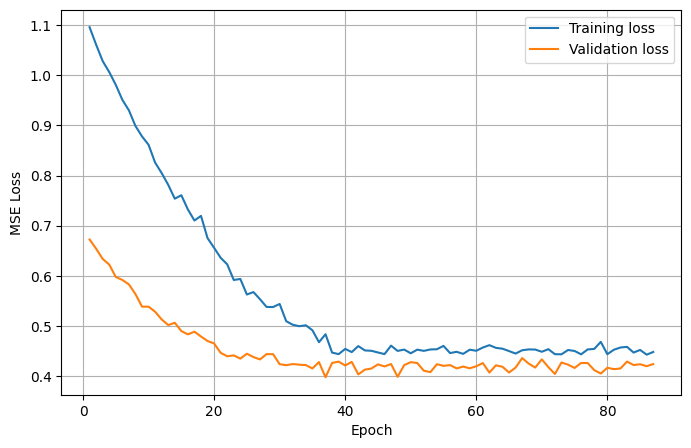

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(epochs, train_losses, label="Training loss")
ax.plot(epochs, val_losses, label="Validation loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.legend()
ax.grid(True)
plt.show()

In [ ]:
fig.savefig('/content/drive/MyDrive/Máster/TFM/Resultados/epoch_sep_fechas.png', dpi=300, bbox_inches="tight")

MSE: tensor(0.2866)


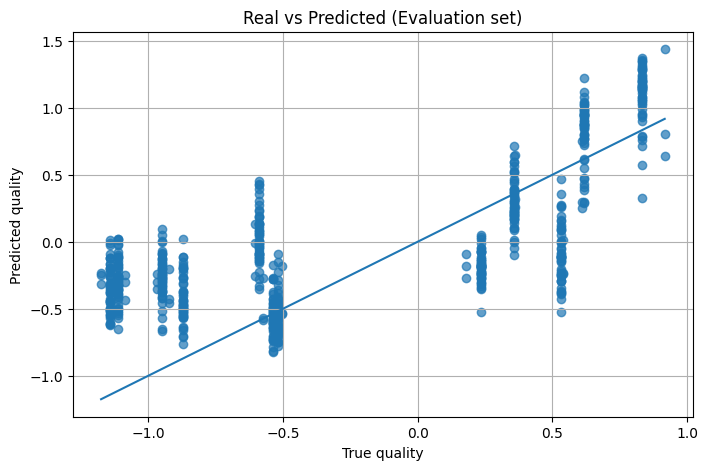

In [ ]:
seq_model.eval()
with torch.no_grad():
  y_test_pred = seq_model(X_test_norm_py)

y_test_pred_np = y_test_pred.squeeze().numpy()
y_true_np = y_test_py.squeeze().numpy()

y_pred = scaler_y.inverse_transform(y_test_pred_np.reshape(-1,1)).ravel()
y_true = scaler_y.inverse_transform(y_true_np.reshape(-1,1)).ravel()

loss_fn = nn.MSELoss()
print('MSE:', loss_fn(y_test_pred, y_test_py))

fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(y_true_np, y_test_pred_np, alpha=0.7)
ax.plot(
    [y_true_np.min(), y_true_np.max()],
    [y_true_np.min(), y_true_np.max()]
)
ax.set_xlabel("True quality")
ax.set_ylabel("Predicted quality")
ax.set_title("Real vs Predicted (Evaluation set)")
ax.grid(True)
plt.show()


In [ ]:
fig.savefig('/content/drive/MyDrive/Máster/TFM/Resultados/realVpred_sep_fechas.png', dpi=300, bbox_inches="tight")

In [ ]:
resultados = pd.DataFrame({
    'True': y_true.ravel(),
    'Predicted': y_pred.ravel()
})
resultados.to_csv('/content/drive/MyDrive/Máster/TFM/Resultados/trueVpred_sep_fechas.csv', decimal='.')

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error

def metricas(y_true, y_pred):
  r2 =r2_score(y_true, y_pred)
  mse = mean_squared_error(y_true, y_pred)
  mae = mean_absolute_error(y_true, y_pred)
  rmse = root_mean_squared_error(y_true, y_pred)
  print('Métricas:')
  print(f'r^2: {r2} \nmean squared error: {mse} \nmean absolute error: {mae} \nroot mean squared error: {rmse}')

In [ ]:
metricas(y_true, y_pred)

Métricas:
r^2: 0.4116525650024414 
mean squared error: 236.37484741210938 
mean absolute error: 12.931325912475586 
root mean squared error: 15.374486923217773


# Modelo de multi-layer perceptron (MLP) con train_test split

In [ ]:
from sklearn.model_selection import train_test_split
def random_split(val_size, test_size, datos, N_folds=1, seed=42):
  all_idx = list(range(len(data)))
  trainval_idx, test_idx = train_test_split(all_idx, test_size=test_size, random_state=seed)
  rel_val_size = val_size / (1.0 - test_size)
  train_idx_dict, val_idx_dict = {}, {}

  train_idx, val_idx = train_test_split(trainval_idx, test_size=rel_val_size,random_state=seed)
  train_idx_dict = list(train_idx)
  val_idx_dict = list(val_idx)

  train_samples = datos.iloc[train_idx_dict, :]
  val_samples = datos.iloc[val_idx_dict, :]
  test_samples = datos.iloc[test_idx, :]
  return train_samples, val_samples, test_samples

In [ ]:
data = pd.get_dummies(data, columns=['clasificacion'], dtype=int)
data = pd.get_dummies(data, columns=['mes'], prefix='mes', dtype=int)
columnas_mcd12q1 = ['LC_Type1', 'LC_Type2', 'LC_Type3', 'LC_Type4', 'LC_Type5', 'LC_Prop1', 'LC_Prop2', 'LC_Prop3']
data = pd.get_dummies(data, columns=columnas_mcd12q1, dtype=int)

train, val, test = random_split(0.1, 0.1, data)

In [ ]:
print(train.shape)
print(val.shape)
print(test.shape)

(2448, 144)
(306, 144)
(306, 144)


In [ ]:
X_train = train.drop(columns='ozone')
X_val = val.drop(columns='ozone')
X_test = test.drop(columns='ozone')

y_train = train[['ozone']]
y_val = val[['ozone']]
y_test = test[['ozone']]



In [ ]:
# Primero dividimos los datos y luego los normalizamos
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train)
X_val_norm = scaler.transform(X_val)
X_test_norm = scaler.transform(X_test)

scaler_y = StandardScaler()
y_train_norm = scaler_y.fit_transform(y_train)
y_val_norm = scaler_y.transform(y_val)
y_test_norm = scaler_y.transform(y_test)

In [ ]:
import copy
def training_loop(n_epochs, optimizer, model, loss_fn, x_train, x_val,
                  y_train, y_val, patience:int=50):

    train_losses = []
    val_losses = []

    best_val = float('inf')
    wait=0
    best_model_state = None
    for epoch in range(1, n_epochs + 1):

        # model.train()
        y_train_pred = model(x_train)
        loss_train = loss_fn(y_train_pred, y_train)

        # model.eval()
        with torch.no_grad():
          y_val_pred = model(x_val)
          loss_val = loss_fn(y_val_pred, y_val)

        optimizer.zero_grad()
        loss_train.backward()
        optimizer.step()

        val_losses.append(loss_val.item())
        train_losses.append(loss_train.item())

        if loss_val < best_val:
          best_val = loss_val
          wait = 0
          best_model_state = copy.deepcopy(model.state_dict())
        else:
          wait +=1

        if wait >= patience:
          print('Early stop')
          break

        if epoch == 1 or epoch % 50 == 0:
            print(f"Epoch {epoch}, Training loss {loss_train.item():.4f},"
                  f" Validation loss {loss_val.item():.4f}")

        if best_model_state is not None:
          model.load_state_dict(best_model_state)

    return train_losses, val_losses

In [ ]:
X_train_norm_py = torch.from_numpy(X_train_norm).float()
X_val_norm_py = torch.from_numpy(X_val_norm).float()
X_test_norm_py = torch.from_numpy(X_test_norm).float()

y_train_py = torch.from_numpy(y_train_norm).float()
y_val_py = torch.from_numpy(y_val_norm).float()
y_test_py = torch.from_numpy(y_test_norm).float()

In [ ]:
seq_model = nn.Sequential(
    nn.Linear(X_train.shape[1], 32),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(16, y_train.shape[1])
)

In [ ]:
optimizer = optim.Adam(seq_model.parameters(), lr=1e-3)

train_losses, val_losses = training_loop(
    n_epochs = 400,
    optimizer = optimizer,
    model = seq_model,
    loss_fn = nn.MSELoss(),
    x_train = X_train_norm_py,
    x_val = X_val_norm_py,
    y_train = y_train_py,
    y_val = y_val_py)


Epoch 1, Training loss 1.1146, Validation loss 1.2459
Epoch 50, Training loss 0.3714, Validation loss 0.4363
Epoch 100, Training loss 0.1963, Validation loss 0.2613
Epoch 150, Training loss 0.1667, Validation loss 0.2083
Epoch 200, Training loss 0.1488, Validation loss 0.2049
Early stop


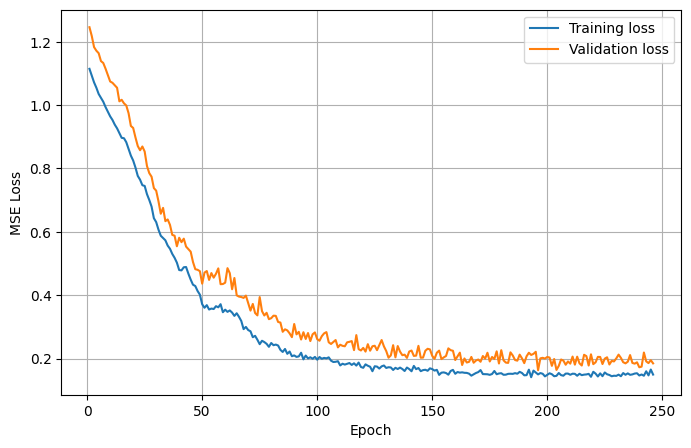

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(epochs, train_losses, label="Training loss")
ax.plot(epochs, val_losses, label="Validation loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.legend()
ax.grid(True)
plt.show()

In [ ]:
fig.savefig('/content/drive/MyDrive/Máster/TFM/Resultados/epoch_sep_random.png', dpi=300, bbox_inches="tight")

MSE: tensor(0.0785)


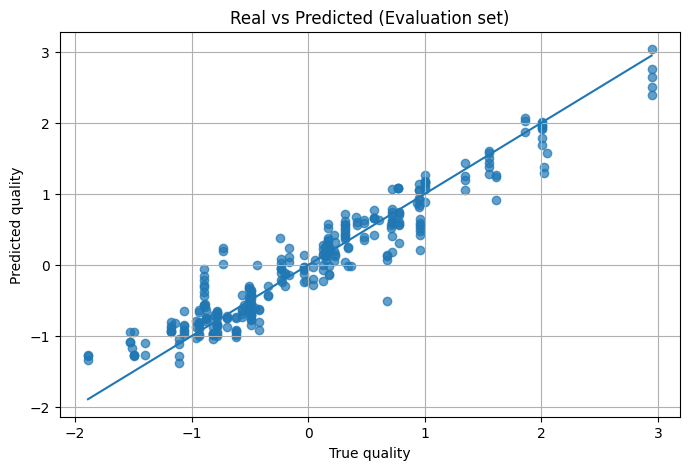

In [ ]:
seq_model.eval()
with torch.no_grad():
  y_test_pred = seq_model(X_test_norm_py)

y_test_pred_np = y_test_pred.squeeze().numpy()
y_true_np = y_test_py.squeeze().numpy()

y_pred = scaler_y.inverse_transform(y_test_pred_np.reshape(-1,1)).ravel()
y_true = scaler_y.inverse_transform(y_true_np.reshape(-1,1)).ravel()

loss_fn = nn.MSELoss()
print('MSE:', loss_fn(y_test_pred, y_test_py))

fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(y_true_np, y_test_pred_np, alpha=0.7)
ax.plot(
    [y_true_np.min(), y_true_np.max()],
    [y_true_np.min(), y_true_np.max()]
)
ax.set_xlabel("True quality")
ax.set_ylabel("Predicted quality")
ax.set_title("Real vs Predicted (Evaluation set)")
ax.grid(True)
plt.show()


In [ ]:
fig.savefig('/content/drive/MyDrive/Máster/TFM/Resultados/realVpred_sep_random.png', dpi=300, bbox_inches="tight")

In [ ]:
resultados = pd.DataFrame({
    'True': y_true.ravel(),
    'Predicted': y_pred.ravel()
})
resultados.to_csv('/content/drive/MyDrive/Máster/TFM/Resultados/trueVpred_sep_random.csv', decimal='.')

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error

def metricas(y_true, y_pred):
  r2 =r2_score(y_true, y_pred)
  mse = mean_squared_error(y_true, y_pred)
  mae = mean_absolute_error(y_true, y_pred)
  rmse = root_mean_squared_error(y_true, y_pred)
  print('Métricas:')
  print(f'r^2: {r2} \nmean squared error: {mse} \nmean absolute error: {mae} \nroot mean squared error: {rmse}')

In [ ]:
metricas(y_true, y_pred)

Métricas:
r^2: 0.9132238030433655 
mean squared error: 53.08418655395508 
mean absolute error: 5.444232940673828 
root mean squared error: 7.285889625549316
